<div align="center">
    <img src="https://www.sharif.ir/documents/20124/0/logo-fa-IR.png/4d9b72bc-494b-ed5a-d3bb-e7dfd319aec8?t=1609608338755" alt="Logo" width="200">
    <p><b>HW1 @ Deep Learning Course, Dr. Soleymani</b></p>
    <p><b>ِDesinged by Amirmahdi Meighani</b></p>
</div>

---



*Full Name:* <br>
$Hossein \ Rezazadeh$

# Efficient Gradient Checkpointing for Memory-Constrained Deep Learning (50 points)
Deep learning experiments are often limited by GPU\memory constraints, making it challenging to train large models. To overcome this, we implemented gradient checkpointing, a technique that significantly reduces memory usage by strategically storing intermediate activations and recomputing them during backpropagation. This allows us to train models that would otherwise exceed our GPU’s memory capacity.

In this guide, you'll first implement gradient checkpointing from scratch to understand its inner workings. Then, you'll learn how to leverage PyTorch's built-in checkpointing feature for more efficient deep learning workflows.

### How Gradient Checkpointing Works
We divide the neural network into segments and only store activations at the segment boundaries (checkpoints). The activations for intermediate layers are discarded and recomputed during backpropagation.

Step-by-Step Process:



*   **Forward Pass (Training Phase)**



1.  Divide the model into segments (e.g., every few layers).
2.  Save activations only at checkpoint layers.
3.  Discard activations of intermediate layers.
4.  Proceed as usual to compute the final output.



*   **Backward Pass (Gradient Calculation)**



1. Recompute missing activations for each segment.
2. Compute gradients using the recomputed activations.
3. Update model parameters with computed gradients.


By recomputing only small segments at a time, we save significant memory while keeping the computational cost manageable.


First import what you need and check your GPU.

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

# TODO: Your imports
from torch.utils.data import TensorDataset, DataLoader  # creating dataset
import numpy as np
from tqdm import tqdm  # Progress bar
import gc # for clearing the duca cache
import matplotlib.pyplot as plt

# End of TODO


In [46]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}") # You must use cuda for this notebook


# Function to measure GPU memory usage
def get_gpu_memory_usage():
    # Todo: return the gpu memory useage for comparison
    return torch.cuda.memory_allocated() / 1024**2
    pass
    # End of Todo

Using device: cuda


We have created a small model for using it with and with out lazy gradient. You can change it if you like.

In [47]:
# Define a model for intensive GPU usage
# You can change it
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()

        self.before = nn.Sequential(
            nn.Linear(200*200, 100),
            nn.ReLU(),
            nn.Linear(100, 32),
            nn.ReLU(),
        )

        self.after = nn.Sequential(
            nn.Linear(32, 3000),
            nn.ReLU(),
            nn.Linear(3000, 200*200),
            nn.ReLU(),
            nn.Linear(200*200, 1),
        )



    def forward(self, x):
        bottleneck_out = self.before(x)             # first checkpoint
        final_out = self.after(bottleneck_out)      # second checkpoint
        return final_out, bottleneck_out




for the next function i define the following: <br>

**Mathematical Definition:**

$$
f(x) = x^2 - 10 \cos\left(2\pi x\right) + 10 \\
$$
*Attention:* 

we consider the input to f(x) mean of every input set so in this case the output have the shape of (-1 , 1)

In [48]:
def create_dataloader(batch_size=128 , n_batches = 1 , input_size = 200*200):
    # Todo: Create synthetic data and return a dataloader
    # The data must be compatible with the model you use
    X = torch.randn(n_batches * batch_size, input_size)
    y = torch.pow(X.mean(axis=1),2) - torch.cos(2*(torch.pi)*X.mean(axis=1)) +10
    dataset = TensorDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader
    # End of Todo


In [49]:
X = create_dataloader().dataset.tensors[0]
print(X.shape)
print(X)

torch.Size([128, 40000])
tensor([[ 2.6461, -1.6032,  2.6027,  ...,  0.3809,  1.9191, -0.8664],
        [-1.3660,  0.7808, -1.2845,  ..., -1.2931,  0.1157,  0.9316],
        [ 1.0883,  0.3909,  0.0085,  ..., -0.4038,  0.6013, -0.1343],
        ...,
        [ 0.0745,  0.5998,  0.3520,  ..., -0.6708,  0.3275,  0.0570],
        [ 0.3105, -1.0120,  0.8180,  ..., -0.7465, -1.6546,  1.0073],
        [ 0.9269,  0.6553, -0.0078,  ...,  2.9180, -0.0120, -1.7256]])


In [50]:
# Training loop
def train_model(use_lazy_grad=False, num_epochs=1 , n_batches = 8):     # for visualizing the training ste (Based on the Already provided graph)
    dataloader = create_dataloader(n_batches=n_batches)
    print('Data is Created')
    model = Model().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    mem_usage = []
    start_time = time.time()

    for epoch in range(num_epochs):
        for batch_x, batch_y in tqdm(dataloader):

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            batch_x.requires_grad = True  # Track gradients
            final_out, bottleneck_out = model(batch_x)
            loss = criterion(final_out , batch_y)


            if use_lazy_grad:
                # Todo: implement the lazy gradient method, using the bottleneck
                # as the only segmentation. You should compute gradient w.r.t
                # bottleneck output and then backpropagate manually
            
                grad_bottleneck = torch.autograd.grad(

                loss,
                bottleneck_out,
                retain_graph=True)[0]
                                        

                bottleneck_out.backward(grad_bottleneck)


                pass
                # End of Todo

            else:

                # Todo: normal back prop of loss
                loss.backward()
                # End of Todo

            optimizer.step()

            mem_usage.append(get_gpu_memory_usage())

    elapsed_time = time.time() - start_time
    return mem_usage, elapsed_time


In [51]:
# TODO:
# Run training with and without lazy gradient propagation

mem_usage_and_elapsed_time = {}

print("|--lazy grad = True--|")
mem_usage, elapsed_time = train_model(use_lazy_grad=True)
mem_usage_and_elapsed_time["lazy_grad_True"] = (mem_usage , elapsed_time)


# Clearing the cuda cache
gc.collect()
torch.cuda.empty_cache()


print("|--lazy grad = False--|")
mem_usage, elapsed_time = train_model(use_lazy_grad=False)
mem_usage_and_elapsed_time["lazy_grad_False"] = (mem_usage , elapsed_time)

# Note that you should empty cache of cuda before, between and after your trainings
# So your results will be valid. Save the mem_usage and elapsed_time of each one


# End of TODO

|--lazy grad = True--|
Data is Created


  0%|          | 0/8 [00:00<?, ?it/s]c:\Users\hossein\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([128])) that is different to the input size (torch.Size([128, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
100%|██████████| 8/8 [00:00<00:00, 21.60it/s]


|--lazy grad = False--|
Data is Created


100%|██████████| 8/8 [00:00<00:00,  9.79it/s]


In [52]:
mem_usage_and_elapsed_time

{'lazy_grad_True': ([601.70458984375,
   601.70458984375,
   602.44580078125,
   601.70458984375,
   602.44580078125,
   601.70458984375,
   602.44580078125,
   601.70458984375],
  0.3724403381347656),
 'lazy_grad_False': ([1955.53515625,
   1955.8076171875,
   1956.2763671875,
   1956.2763671875,
   1956.2763671875,
   1956.2763671875,
   1956.2763671875,
   1956.2763671875],
  0.8169212341308594)}

In [53]:
print(
    f"""|--with lazy gradient--|
memory usage is: {np.mean(mem_usage_and_elapsed_time["lazy_grad_True"][0])}
elapsed time is: {mem_usage_and_elapsed_time["lazy_grad_True"][1]}
"""
)


|--with lazy gradient--|
memory usage is: 601.9825439453125
elapsed time is: 0.3724403381347656



In [54]:
print(
    f"""|--without lazy gradient--|
memory usage is: {np.mean(mem_usage_and_elapsed_time["lazy_grad_False"][0])}
elapsed time is: {mem_usage_and_elapsed_time["lazy_grad_False"][1]}
"""
)


|--without lazy gradient--|
memory usage is: 1956.1251220703125
elapsed time is: 0.8169212341308594



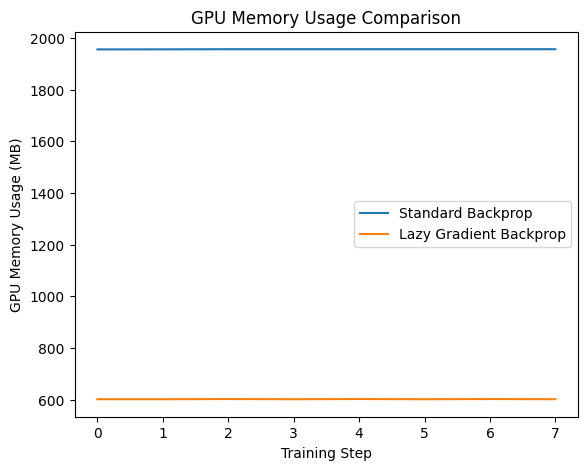

In [55]:
mem_lazy, time_lazy = mem_usage_and_elapsed_time["lazy_grad_True"]
mem_normal, time_normal = mem_usage_and_elapsed_time["lazy_grad_False"]

plt.figure(figsize=(6.5,5))

plt.plot(mem_normal, label="Standard Backprop")
plt.plot(mem_lazy, label="Lazy Gradient Backprop")


plt.xlabel("Training Step")
plt.ylabel("GPU Memory Usage (MB)")
plt.title("GPU Memory Usage Comparison")
plt.legend()

plt.show()


PyTorch provides a built-in gradient checkpointing feature through torch.utils.checkpoint. This makes it easy to implement checkpointing without manually managing activation storage and recomputation.



First, let's create a simple Sequential model and checkpoint it. We can also verify that the checkpointing doesn't change the value of gradients or the activations.

In [56]:
import torch.nn as nn
from torch.utils.checkpoint import checkpoint_sequential
from collections import OrderedDict

# TODO: create a simple Sequential model and then create the model inputs.
model = nn.Sequential(
    OrderedDict(
        [
            ("Layer 1" , nn.Linear(10*10 , 300)),
            ("act_lay_1_relu" , nn.ReLU()),
            ("Layer 2" , nn.Linear(300 , 150)),
            ("act_lay_2_relu" , nn.ReLU()),
            ("Output" , nn.Linear(150 , 1))
        ]
    )
)


# creating the data:
X = create_dataloader(n_batches=10 , input_size=10*10).dataset.tensors[0]
X.requires_grad_(True)
print(f"here's input (X): \n" , X ,"\n","X.shape: ", X.shape)

# get the modules in the model. These modules should be in the order

model_modules = list((model._modules).values()) # or the list(model.children()) returns exactly the same 
print(f"here's the model modules:")      
for i in enumerate(model_modules , start=1):
    print(i)


# the model should be executed. Then set the number of checkpoint segments.

n_segments = 2

# Now call the checkpoint API and get the output.

out = checkpoint_sequential(model_modules , n_segments , X , use_reentrant=False)

# finally run the backwards pass on the model. For backwards pass, for simplicity,
# we won't calculate the loss and rather backprop on output.sum()

loss = out.sum()
loss.backward()
# End of TODO

# Now we save the output and parameter gradients that we will use for
# comparison purposes with the non-checkpointed run.
output_checkpointed = out.data.clone()
grad_checkpointed = {}
for name, param in model.named_parameters():
    grad_checkpointed[name] = param.grad.data.clone()


here's input (X): 
 tensor([[-1.1912, -2.0407,  1.8545,  ...,  3.7867, -1.0936,  0.8418],
        [-1.3818, -0.7021, -2.0998,  ...,  1.3355,  0.9391,  0.0187],
        [ 0.1876,  0.2774,  0.4770,  ..., -1.0866,  1.0464,  1.3841],
        ...,
        [-1.6507,  0.5128,  0.0878,  ...,  0.3015, -0.6256,  2.0552],
        [ 0.1742, -0.5278,  2.3523,  ..., -0.6268, -1.3439,  1.4577],
        [-0.8341,  0.5340,  1.0157,  ..., -1.5059,  0.2474, -1.3928]],
       requires_grad=True) 
 X.shape:  torch.Size([1280, 100])
here's the model modules:
(1, Linear(in_features=100, out_features=300, bias=True))
(2, ReLU())
(3, Linear(in_features=300, out_features=150, bias=True))
(4, ReLU())
(5, Linear(in_features=150, out_features=1, bias=True))


Now that we have executed the checkpointed pass on the model, let's also run the non-checkpointed model and verify that the checkpoint API doesn't change the model outputs or the parameter gradients.

In [57]:
# TODO: use the non-checkpointed mode. create a new variable using the same
# tensor data. get the model output.
X_no_checkpoint  = X.detach().clone().requires_grad_(True)
out_no_checkpoint = model(X_no_checkpoint)


# End of TODO


# save the output and parameter gradients values
out_not_checkpointed = out.data.clone()
grad_not_checkpointed = {}
for name, param in model.named_parameters():
    grad_not_checkpointed[name] = param.grad.data.clone()

Now that we have done the checkpointed and non-checkpointed pass of the model and saved the output and parameter gradients, let's compare their values

In [58]:
# TODO: compare the output and parameters gradients with and without checkpoint.
# they must be equal.
if torch.allclose(out_not_checkpointed , output_checkpointed):  # for ensuring that the output tensors are the same
    print("Yes")
else:
    print("NO")
# End of TODO

print("All checks passed!")

Yes
All checks passed!


So, from this example, we can see that it's very easy to use checkpointing on Sequential models and that the checkpoint API doesn't alter any data. The Checkpoint API implementation is based on autograd and hence there is no need for explicitly specifying what the execution of backwards should look like

# Gradient Accumulation in Deep Learning (25 points)


### 1. Introduction

Training deep learning models with large batch sizes can be difficult due to memory limitations, especially when using large datasets or deep networks. **Gradient Accumulation** is a technique that allows us to simulate large batch sizes without increasing memory usage. This tutorial will cover:

1. **The theory behind Gradient Accumulation**
2. **Using it in PyTorch**
3. **Observing its effects**

---

## 2. Theory Behind Gradient Accumulation

### 2.1 What is Gradient Accumulation?
Instead of updating the model parameters after every mini-batch, **Gradient Accumulation** allows us to accumulate gradients over multiple mini-batches before performing an update. This effectively simulates training with a larger batch size.  
*in other words* instead of effecting the gradient on every neuron for each batch, sum the effects on every n mini batch

### 2.2 Why Use Gradient Accumulation?
- **Overcome Memory Limits**: Training with large batch sizes often exceeds GPU memory capacity. Accumulating gradients allows training on smaller mini-batches while maintaining the benefits of larger batch training.
- **Stable Training**: Larger batch sizes help in stable updates and reducing variance in gradient estimation.
- **Effective Batch Size**: If GPU memory allows batch size `B` but we need `N`, we can accumulate gradients for `N/B` steps before updating.

### 2.3 How Does It Work?
If `loss` is computed on `batch_size = B`, instead of calling `optimizer.step()` every step, we:
1. Compute gradients on `B` and accumulate them.
2. Repeat for `K` iterations, accumulating gradients.
3. Update weights only after `K` steps.
4. Reset gradients after update.

This results in an **effective batch size** of `B * K` without needing extra memory.


first create a simple model and implement the function to train with accumulation.

In [70]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_with_gradient_accumulation(model, dataloader, accumulation_steps):
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    model.train()
    optimizer.zero_grad()
    mem_usage = []

    for batch_idx, (inputs, targets) in enumerate(dataloader):
        # TODO: Get loss and Normalize loss by accumulation steps
        # Then backpropagate loss.  Accumulate gradients and update after
        # `accumulation_steps`

        inputs, targets = inputs.to(device), targets.to(device) # GPU Configuration

        outputs = model(inputs)

        loss = criterion(outputs , targets)

        loss = loss / accumulation_steps

        loss.backward()

        
        if ((batch_idx + 1) % accumulation_steps == 0) or (batch_idx + 1 == len(dataloader)):  # or we can set start=1 in the main for loop, enumerate function 
            optimizer.step()      
            optimizer.zero_grad()

        if torch.cuda.is_available():
            mem_usage.append(torch.cuda.memory_allocated() / 1024**2)   # output is Byte, we convert it to MB
        
        # End of TODO


    return mem_usage


# TODO: Define a simple model
class SimpleModel(nn.Module):
    def __init__(self , input_dim = 100 , hidden_dim = 2*(100) , output_dim = 1):
        super(SimpleModel , self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        self.fc1 = nn.Linear(self.input_dim , self.hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(self.hidden_dim , self.output_dim)


    def forward(self , X):
        X = self.fc1(X)
        X = self.relu(X)
        X = self.fc2(X)

        return X

# End of TODO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleModel().to(device)

Now create a dataloader with the mentioned parameters

In [71]:
def create_dataloader(batch_size, accumulation_steps):
    # TODO: create dataloader with batch size and same number of samples
    # for different accumulation_steps

    total_samples = 4000    # for example    

    X = torch.randn(total_samples, 100)
    y = torch.pow(X.mean(axis=1),2) - torch.cos(2*(torch.pi)*X.mean(axis=1)) +10
    y = y.unsqueeze(1)
    dataset = TensorDataset(X, y)
    batch_size = total_samples//accumulation_steps      # game changer line
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

    # End of TODO

Lets train with accumulation and save mem usage.

In [72]:
batch_size = 100  # Small batch size due to memory limits you can change it
effective_batch_size = 400
accumulation_steps = effective_batch_size // batch_size

# TODO: train with accumulation_steps and save mem_usage
# dont forget to empty cuda cache

# Clearing the cuda cache
torch.cuda.empty_cache()

dataloader = create_dataloader(batch_size=batch_size , accumulation_steps=accumulation_steps)

mem_usage = train_with_gradient_accumulation(model , dataloader , accumulation_steps)
torch.cuda.empty_cache()

print(f"memory usage is: {mem_usage}")
print(len(mem_usage))
# End of TODO

memory usage is: [18.619140625, 18.619140625, 18.619140625, 18.5400390625]
4


And now train in the classic way with no accumulation.

In [74]:
# TODO: train with accumulation_steps=1 (it means standard back prop)
# and save mem_usage
# Clearing the cuda cache
accumulation_steps = 1
torch.cuda.empty_cache()

dataloader = create_dataloader(batch_size=batch_size , accumulation_steps=accumulation_steps)

standard_mem_usage = train_with_gradient_accumulation(model , dataloader , accumulation_steps)

torch.cuda.empty_cache()

print(f"standard memory usage is: {standard_mem_usage}")

print(f"len(standard_mem_usage): {len(standard_mem_usage)}")

plot_standard_mem_usage = standard_mem_usage * len(mem_usage)

print(f"len(plot_standard_mem_usage)= {len(plot_standard_mem_usage)}")
print(plot_standard_mem_usage)

# End of TODO

standard memory usage is: [19.70751953125]
len(standard_mem_usage): 1
len(plot_standard_mem_usage)= 4
[19.70751953125, 19.70751953125, 19.70751953125, 19.70751953125]


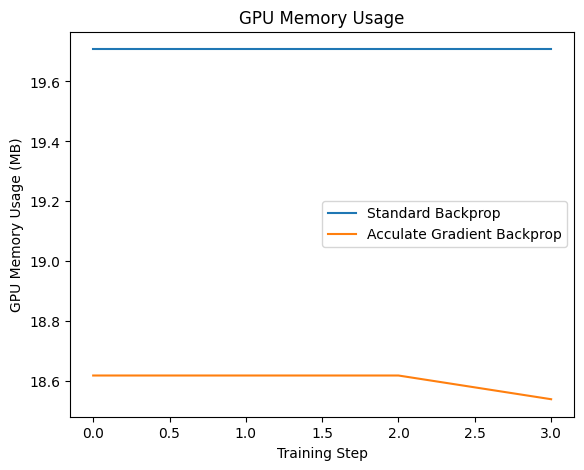

In [75]:
plt.figure(figsize=(6.5,5))

plt.plot(plot_standard_mem_usage, label="Standard Backprop")
plt.plot(mem_usage, label="Acculate Gradient Backprop")



plt.xlabel("Training Step")
plt.ylabel("GPU Memory Usage (MB)")
plt.title("GPU Memory Usage")
plt.legend()

plt.show()


Check if we actually used less memory:

##  Conclusion

- **Gradient Accumulation** helps simulate large batch sizes without requiring more memory.
- It improves **training stability** and allows training on **memory-constrained GPUs**.
- We implemented it **from scratch** and in **PyTorch**.
- We visualized its **effects** on loss stabilization.

Gradient Accumulation is a useful trick when working with **deep networks and large datasets** on limited hardware. 🚀


# Sources of Randomness (5 points)
run the code below. the outputs are different. Why do you think this happened?

In [76]:
input = torch.randn(1, 5).to(device)
model = SimpleModel(input_dim=5, hidden_dim=1500,output_dim=1).to(device)

out = model(input)
print(out)

model = SimpleModel(input_dim=5, hidden_dim=1500,output_dim=1).to(device)

out = model(input)
print(out)

tensor([[0.0407]], device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([[0.0343]], device='cuda:0', grad_fn=<AddmmBackward0>)


## Controlling Sources of Randomness in PyTorch Models (with GPU)

### Introduction
Randomness plays a crucial role in deep learning, but uncontrolled randomness can lead to inconsistent results. This part explores the sources of randomness in PyTorch and how to control them, especially when using a GPU.

---

## **1. Understanding Sources of Randomness**
In PyTorch, randomness can come from multiple sources:

1. **Python's built-in random module**: Used for operations that involve randomness in Python code.
2. **NumPy**: If NumPy is used for data augmentation or initialization.
3. **PyTorch CPU Randomness**: Random initialization of weights, dropout layers, etc.
4. **PyTorch GPU Randomness**: When CUDA is used, operations can be non-deterministic.
5. **cuDNN Backend**: NVIDIA's cuDNN has optimizations that may introduce non-determinism.

To get reproducible results, all these sources must be controlled.

## **2. Setting Seeds in PyTorch**
To control randomness, we define a function that sets the seed for all sources:

In [77]:
import os
import random
import numpy as np
import torch

def set_seed(seed):
    # TODO: set these seeds:
    # Python Hash seed
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Python random module
    random.seed(seed)
    # NumPy seed
    np.random.seed(seed)
    # PyTorch CPU seed
    torch.manual_seed(seed=seed)
    # PyTorch CUDA seed
    # Multi-GPU seed
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Ensure deterministic cudnn
    torch.backends.cudnn.deterministic = True
    # Disables optimization that may introduce randomness(benchmark)
    print(f"Seeds have been set to: {seed}")

    pass

    # End of TODO



Now check if the results are the same:

In [78]:
input = torch.randn(1, 5).to(device)

set_seed(123)  # Set seed to 123 (or any fixed value)
model = SimpleModel(input_dim=5, hidden_dim=1500,output_dim=1).to(device)

out = model(input)
print(out)

set_seed(123)  # Set seed to 123 (or any fixed value)

model = SimpleModel(input_dim=5, hidden_dim=1500,output_dim=1).to(device)

out = model(input)
print(out)

Seeds have been set to: 123
tensor([[0.0764]], device='cuda:0', grad_fn=<AddmmBackward0>)
Seeds have been set to: 123
tensor([[0.0764]], device='cuda:0', grad_fn=<AddmmBackward0>)


## **Key Takeaways**
1. Randomness in PyTorch comes from multiple sources: Python, NumPy, PyTorch (CPU & GPU), and cuDNN.
2. Using `set_seed()` ensures reproducibility in experiments.
3. cuDNN optimizations can introduce non-determinism; setting `torch.backends.cudnn.deterministic = True` helps mitigate this.
4. Always set the seed before model initialization to ensure identical starting conditions.

Reproducibility is critical for debugging and fair benchmarking of deep learning models. 🚀


**Note**

Setting torch.backends.cudnn.deterministic = True makes the code slower because it forces cuDNN to use deterministic algorithms instead of its default highly-optimized, non-deterministic implementations. Here’s why:
1. cuDNN Optimizations

cuDNN (CUDA Deep Neural Network Library) provides highly optimized implementations of deep learning operations, such as convolutions and matrix multiplications. By default, cuDNN selects the fastest algorithm available based on the given input size, hardware, and configuration.
2. Deterministic vs. Non-Deterministic Algorithms

Some of cuDNN’s fastest algorithms introduce minor sources of randomness due to floating-point precision differences in parallel execution, particularly in:

    Convolution operations (e.g., torch.nn.Conv2d)
    Batch normalization
    Recurrent layers (e.g., LSTMs)

When torch.backends.cudnn.deterministic = True, PyTorch forces cuDNN to use only deterministic versions of these algorithms. However, deterministic algorithms are not always the most optimized ones, leading to slower performance.

# Second-Order Gradients in Deep Learning (20 points)

What are Second-Order Gradients?

In deep learning, second-order gradients refer to the derivatives of gradients (i.e., the second derivative of a loss function with respect to model parameters). These are commonly used in optimization methods that require information about the curvature of the loss function.



### **Mathematically**:
- **First-order gradient**: $ g = \nabla_\theta L(\theta) $ (gradient of loss $ L $ w.r.t. parameters $ \theta $)
- **Second-order gradient (Hessian)**: $ H = \nabla^2_\theta L(\theta) $ (derivative of $ g $, which captures curvature)


###**Why Use Second-Order Gradients?**

 *   Better Optimization – Second-order methods like Newton’s Method use curvature information to converge faster than first-order methods (like SGD).
 *    Natural Gradient Descent – Second-order gradients help in adapting the learning rate in different directions based on the Hessian matrix.
 *   Meta-Learning – Algorithms like MAML (Model-Agnostic Meta-Learning) require second-order gradients to update learning rates.
 *   Adversarial Training – Computing second-order derivatives is useful for generating adversarial examples.
 *   Regularization – Used in some regularization techniques like curvature-based penalties.



###**Challenges of Second-Order Gradients**

 * Computationally Expensive – Computing second-order derivatives (Hessian) can be costly, especially for deep networks.
 * Memory Intensive – Requires additional memory, making it impractical for very large models.
 * Numerical Stability – Sometimes leads to unstable gradients and requires careful tuning.

The second derivative (Hessian matrix) provides information about how the gradient changes. By moving in the direction of the second-order gradient, we can adaptively adjust step sizes based on how steep or flat the loss landscape is.

In the simplest case:

$
θ′=θ−α∇L(θ)−β∇2L(θ)
$

where:

 * ∇2L(θ) (the second-order gradient) adjusts the update based on curvature,
 * β is a small scaling factor.

In [79]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: define a model (1d to 1d)
        self.linear = nn.Linear(in_features=1, out_features=1)
        # End of TODO

    def forward(self, x):
        # TODO: implement forward
        return self.linear(x)
        # End of TODO


def generate_data():
    # TODO: Generate data for 1d to 1d model
    # a simple linear data with noise is ok. For example: y = 2x + 3 + noise
    x = torch.linspace(0, 10, 100).reshape(-1, 1) 
    noise = torch.randn(x.size()) * 0.5
    y = 2 * x + 3 + noise
    # End of TODO
    return x, y


model = SimpleNet()
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


x_train, y_train = generate_data()
num_epochs = 100

In [81]:
for epoch in range(num_epochs):

    # TODO: implement the loop using second-order gradients.
    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    # first, compute first-order gradient. Then Convert first-order gradient
    grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)
    # to scalar before computing second-order gradient Update parameters
    # manually. using first order and second order gradients.
    for param, grad in zip(model.parameters(), grads):
        grad_scalar = grad.pow(2).sum() 
        grad2 = torch.autograd.grad(grad_scalar, param, retain_graph=True)[0]
        with torch.no_grad():
            lr = 0.1    
            step = grad / (grad2 + 1e-6)
            param -= lr * step

    optimizer.zero_grad()
    # print loss in every step


    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.6f}")

    pass
    # End of TODO


print("Training complete!")


Epoch 1/100 - Loss: 259.673859
Epoch 2/100 - Loss: 260.558868
Epoch 3/100 - Loss: 261.445557
Epoch 4/100 - Loss: 262.333893
Epoch 5/100 - Loss: 263.223846
Epoch 6/100 - Loss: 264.115479
Epoch 7/100 - Loss: 265.008789
Epoch 8/100 - Loss: 265.903748
Epoch 9/100 - Loss: 266.800385
Epoch 10/100 - Loss: 267.698669
Epoch 11/100 - Loss: 268.598602
Epoch 12/100 - Loss: 269.500244
Epoch 13/100 - Loss: 270.403503
Epoch 14/100 - Loss: 271.308441
Epoch 15/100 - Loss: 272.215027
Epoch 16/100 - Loss: 273.123291
Epoch 17/100 - Loss: 274.033203
Epoch 18/100 - Loss: 274.944794
Epoch 19/100 - Loss: 275.858002
Epoch 20/100 - Loss: 276.772888
Epoch 21/100 - Loss: 277.689453
Epoch 22/100 - Loss: 278.607666
Epoch 23/100 - Loss: 279.527527
Epoch 24/100 - Loss: 280.449066
Epoch 25/100 - Loss: 281.372253
Epoch 26/100 - Loss: 282.297119
Epoch 27/100 - Loss: 283.223663
Epoch 28/100 - Loss: 284.151825
Epoch 29/100 - Loss: 285.081635
Epoch 30/100 - Loss: 286.013153
Epoch 31/100 - Loss: 286.946320
Epoch 32/100 - Lo

In [82]:
print("|--in case of printing every 10th epoch training--|")
for epoch in range(num_epochs):

    # TODO: implement the loop using second-order gradients.
    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    # first, compute first-order gradient. Then Convert first-order gradient
    grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)
    # to scalar before computing second-order gradient Update parameters
    # manually. using first order and second order gradients.
    for param, grad in zip(model.parameters(), grads):
        grad_scalar = grad.pow(2).sum() 
        grad2 = torch.autograd.grad(grad_scalar, param, retain_graph=True)[0]
        with torch.no_grad():
            lr = 0.1    
            step = grad / (grad2 + 1e-6)
            param -= lr * step

    optimizer.zero_grad()
    # print loss in every step

    if (epoch + 1) % 10 == 0 or epoch == 0: 
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.6f}")

    pass
    # End of TODO


print("Training complete!")


|--in case of printing every 10th epoch training--|
Epoch 1/100 - Loss: 356.393555
Epoch 10/100 - Loss: 365.912811
Epoch 20/100 - Loss: 376.647430
Epoch 30/100 - Loss: 387.548157
Epoch 40/100 - Loss: 398.614929
Epoch 50/100 - Loss: 409.847687
Epoch 60/100 - Loss: 421.246521
Epoch 70/100 - Loss: 432.811401
Epoch 80/100 - Loss: 444.542358
Epoch 90/100 - Loss: 456.439331
Epoch 100/100 - Loss: 468.502411
Training complete!


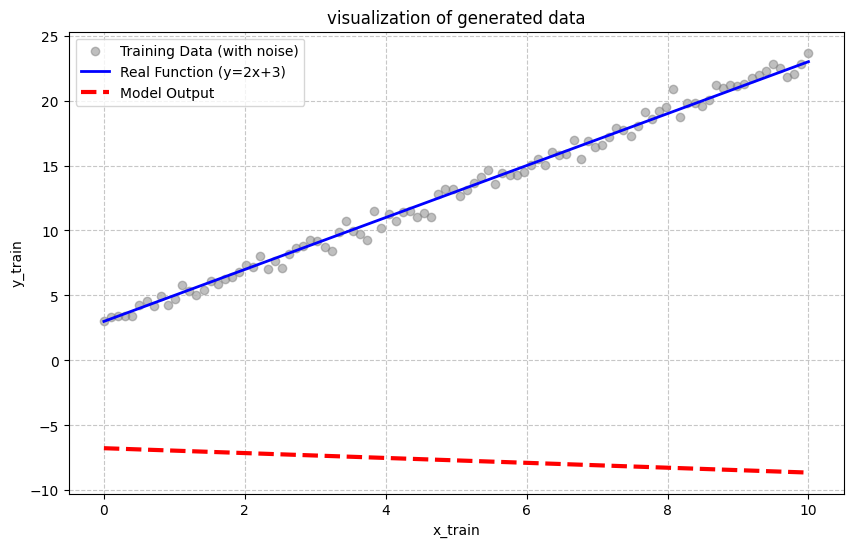

Final learned weight (w): -0.1878
Final learned bias (b): -6.7648


In [84]:
# TODO: evaluate the model using some data and visuilize the model output
# and compare it with the real function
import matplotlib.pyplot as plt

model.eval() 
with torch.no_grad(): 
    
    x_test = torch.linspace(0, 10, 50).reshape(-1, 1)
    
    
    y_predicted = model(x_test)
    
   
    y_real = 2 * x_test + 3


x_test_np = x_test.numpy()
y_predicted_np = y_predicted.numpy()
y_real_np = y_real.numpy()
x_train_np = x_train.numpy()
y_train_np = y_train.numpy()


plt.figure(figsize=(10, 6))


plt.scatter(x_train_np, y_train_np, color='gray', alpha=0.5, label='Training Data (with noise)')


plt.plot(x_test_np, y_real_np, color='blue', linewidth=2, label='Real Function (y=2x+3)')


plt.plot(x_test_np, y_predicted_np, color='red', linestyle='--', linewidth=3, label='Model Output')

plt.title('visualization of generated data')
plt.xlabel('x_train')
plt.ylabel('y_train')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Final learned weight (w): {model.linear.weight.item():.4f}")
print(f"Final learned bias (b): {model.linear.bias.item():.4f}")

# End of TODO

## Interpretation of Moving in the Second-Order Direction

* If the second derivative is large (high curvature) → The loss is changing rapidly → Smaller step sizes.
* If the second derivative is small (low curvature) → The loss changes slowly → Larger step sizes.

This is the core idea behind Newton's method